# NicheSphere tutorial (PIC-seq)

NicheSphere is an sc-verse compatible Python library that identifies differentially co-localised cellular niches based on cell type pair co-localization probabilities across conditions. These probabilities are derived from deconvoluted spatial transcriptomics / PIC-seq data (i.e. the probability of finding each cell type in a given spot or multiplet), and are used to estimate the probability of finding each cell type pair together.

NicheSphere can also identify differentially communicating cellular niches based on Ligand-Receptor (LR) interaction data, such as the output of [pyCrossTalkeR](https://github.com/CostaLab/pyCrossTalkeR).

Finally, NicheSphere combines co-localization and communication networks into communication-weighted co-localization distances, enabling the identification of differentially interacting niches.

**In this tutorial**, we apply NicheSphere to [this bone marrow fibrosis PIC-seq data](https://www.biorxiv.org/content/10.64898/2026.03.16.711605v1.full) to explore the bone marrow fibrosis-related cellular microenvironment. We will:

1. Load PIC-seq deconvolution results and the matching scRNA-seq data
2. Compute condition specific co-localization of cell type pairs
3. Build and explore a differential co-localization network, including niche detection
4. Compute process-based differential cell-cell communication (using CrossTalkeR output)
5. Combine co-localization and communication into localized differential communication networks
6. Visualize selected ligand-receptor relationships with Sankey diagrams


**Please install the development version of NicheSphere directly from GitHub**

```bash
pip install git+https://github.com/CostaLab/NicheSphere@dev

## 1. Setup

Import the libraries needed for this tutorial.

In [1]:
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import warnings
import scanpy as sc
import time
import nichesphere

warnings.filterwarnings("ignore")


NicheSphere also relies on two companion packages for parts of this tutorial:

- [pyCrossTalkeR](https://github.com/CostaLab/pyCrossTalkeR) to compute ligand-receptor communication scores per condition
- [community-layout](https://github.com/CostaLab/community_layout) to lay out community-detected networks

We import these where they are needed below.

## 2. Input data

NicheSphere requires three inputs:

1. **Cell type proportions per spot/multiplet**, obtained by deconvoluting spatial transcriptomics or PIC-seq data with a method of choice (here we used [BayesPrism](https://github.com/Danko-Lab/BayesPrism), but any method returning a table of cell type proportions per spot/multiplet works).
2. **scRNA-seq data** ("singlets") from the same biological system, used to build a background distribution for differential co-localization testing.
3. **Spatial/multiplet ("doublet") sequencing data**, used to identify the conditions/samples present.

### Cell type proportions in doublets/spots

In [2]:
CTprops = pd.read_csv('../../data/BM_PICseq/PICseq_doublets_CTprops.csv', index_col=0)
CTprops.head()


,DC,InfiltMac,Fibro,MonoPro,Neut2,Ly6ClowMac,Baso,TCells,Neut1,MK,ResMac,OsteoCAR,EC,Ery,Spp1+Mac,BCells
IS3_AAACCCAAGAGTCAGC-1,0.022321,0.009692,0.002134,0.019810,0.027176,0.005223,0.005350,0.006909,0.859264,0.013108,0.004198,0.002142,0.004581,0.008093,0.008558,0.001440
IS3_AAACCCAAGGGCTGAT-1,0.009302,0.013937,0.003087,0.008581,0.013993,0.868811,0.012865,0.014621,0.009612,0.008361,0.005726,0.003589,0.009012,0.008289,0.008231,0.001982
IS3_AAACCCACACGCCAGT-1,0.675809,0.260256,0.001310,0.006162,0.004601,0.005598,0.004135,0.005520,0.009202,0.010234,0.002177,0.001419,0.002356,0.006113,0.004108,0.001000
IS3_AAACCCACACTACCGG-1,0.002942,0.003383,0.001131,0.850736,0.101740,0.002235,0.004787,0.002345,0.007967,0.005849,0.001834,0.001331,0.002962,0.003802,0.006055,0.000903
IS3_AAACCCACAGATCCTA-1,0.030429,0.079342,0.005465,0.013012,0.047528,0.643361,0.025168,0.012989,0.035907,0.018483,0.043229,0.005768,0.010787,0.014002,0.010533,0.003997


The cell type probabilities should sum to 1 for each spot/multiplet:

In [3]:
CTprops.sum(axis=1).head()


IS3_AAACCCAAGAGTCAGC-1    1.0
IS3_AAACCCAAGGGCTGAT-1    1.0
IS3_AAACCCACACGCCAGT-1    1.0
IS3_AAACCCACACTACCGG-1    1.0
IS3_AAACCCACAGATCCTA-1    1.0
dtype: float64

### scRNA-seq data (singlets)

In [4]:
adata_singlets = sc.read('../../data/BM_PICseq/PICseq_singlets.h5ad')
adata_singlets.obs.annotation = list(adata_singlets.obs.annotation)


### Multiplet/spot sequencing data

In [5]:
adata_doublets = sc.read('../../data/BM_PICseq/PICseq_doublets.h5ad')


## 3. Differential co-localization analysis

We first compute cell type pair co-localization probabilities from the deconvolution results using `coloc.getColocProbs`. This returns concatenated co-localization matrices (cell type x cell type) per sample, with the sample indicated in the last column.

In [6]:
CTcolocalizationP = nichesphere.coloc.getColocProbs(CTprobs=CTprops, spotSamples=adata_doublets.obs.stage)
CTcolocalizationP.head()


,DC,InfiltMac,Fibro,MonoPro,Neut2,Ly6ClowMac,Baso,TCells,Neut1,MK,ResMac,OsteoCAR,EC,Ery,Spp1+Mac,BCells,sample
DC,0.018899,0.003145,0.002420,0.009168,0.004171,0.001827,0.001256,0.003089,0.006253,0.005446,0.002721,0.001507,0.001714,0.006465,0.003841,0.000943,EV
InfiltMac,0.003145,0.007253,0.001322,0.003761,0.002179,0.001766,0.000631,0.001563,0.002736,0.001967,0.001844,0.000794,0.000946,0.002822,0.002009,0.000496,EV
Fibro,0.002420,0.001322,0.020764,0.005082,0.002962,0.001163,0.000904,0.001726,0.004088,0.002725,0.001727,0.002111,0.001767,0.004005,0.002702,0.000876,EV
MonoPro,0.009168,0.003761,0.005082,0.055366,0.011903,0.003358,0.002878,0.005730,0.016713,0.012703,0.004622,0.003131,0.003569,0.014315,0.007889,0.002072,EV
Neut2,0.004171,0.002179,0.002962,0.011903,0.016147,0.002004,0.001496,0.003008,0.011881,0.004586,0.002610,0.001726,0.001901,0.007352,0.004330,0.001248,EV


We keep track of same-cell-type pairs (e.g. `Fibro-Fibro`), since these are typically excluded from downstream analyses:

In [7]:
oneCTints = CTcolocalizationP.columns[:-1] + '-' + CTcolocalizationP.columns[:-1]


Next, we reshape the co-localization data into a matrix of cell type pairs x samples with `coloc.reshapeColoc`. Set `complete=1` if your co-localization data contains both directions of a pair (`ct1-ct2` and `ct2-ct1`); set `complete=0` if it does not.

In [8]:
colocPerSample = nichesphere.coloc.reshapeColoc(CTcoloc=CTcolocalizationP, complete=1)
colocPerSample


,DC-DC,DC-InfiltMac,DC-Fibro,DC-MonoPro,DC-Neut2,DC-Ly6ClowMac,DC-Baso,DC-TCells,DC-Neut1,DC-MK,...,BCells-Baso,BCells-TCells,BCells-Neut1,BCells-MK,BCells-ResMac,BCells-OsteoCAR,BCells-EC,BCells-Ery,BCells-Spp1+Mac,BCells-BCells
EV,0.018899,0.003145,0.002420,0.009168,0.004171,0.001827,0.001256,0.003089,0.006253,0.005446,...,0.000338,0.000741,0.001673,0.001140,0.000657,0.000472,0.000449,0.00168,0.001045,0.004976
TPO,0.043204,0.011930,0.000577,0.007006,0.002704,0.004632,0.001131,0.001506,0.005417,0.004213,...,0.000112,0.000134,0.000347,0.000144,0.000150,0.000077,0.000050,0.00007,0.000078,0.000504


Co-localization probabilities of all cell type pairs should sum to 1 per sample:

In [9]:
colocPerSample.sum(axis=1)


EV     1.0
TPO    1.0
dtype: float64

### Background distribution and observed vs. expected ratios

In this dataset we do not have replicate samples per condition, so we test differential co-localization by comparing observed co-localization probabilities to a background distribution. The background is generated by randomly pairing cells from the scRNA-seq (singlets) data of the same condition to form synthetic "doublets", and computing the resulting observed/expected (O/E) co-localization ratios. By default we generate 1000 random background doublet sets per cell type pair.


### Building the background distribution

We compute the background distribution from the singlets data of the `TPO` condition. Here, the cell type proportions in the gated singlets data were biased (Fibroblast and OsteoCAR cells were over-represented), so we downsample these two cell types by a factor of 6 to better reflect their true in-tissue proportions before sampling random doublets.

In [10]:
t = time.time()
res = nichesphere.tl.get_PIC_BG_OEratios_DF(
    adata=adata_singlets[adata_singlets.obs.stage == 'TPO'],
    annot_col='annotation',
    target_pairs=colocPerSample.columns,
    nreps=1000,
    njobs=10,
    downsample_cells=True,
    cell_list_downsample=['Fibro', 'OsteoCAR'],
    downsampling_factor=6,
)
bg_df = res  # get_PIC_BG_OEratios_DF already returns the concatenated DataFrame
print(time.time() - t)


52.4618034362793
52.50118970870972


In [11]:
bg_df.head()

,DC-DC,DC-InfiltMac,DC-Fibro,DC-MonoPro,DC-Neut2,DC-Ly6ClowMac,DC-Baso,DC-TCells,DC-Neut1,DC-MK,...,BCells-Baso,BCells-TCells,BCells-Neut1,BCells-MK,BCells-ResMac,BCells-OsteoCAR,BCells-EC,BCells-Ery,BCells-Spp1+Mac,BCells-BCells
OE_Ratio,0.947224,1.060056,5.559794e-11,1.236195,0.929457,0.890595,1.103392,1.350236,0.860871,1.133869,...,1.863945e-10,3.756832e-10,1.696634e-10,5.959113e-10,1.362275e+00,1.344111e-08,6.235567e-10,2.240185e-09,8.064667e-09,6.366842e-09
OE_Ratio,1.380241,0.983656,5.947687e-11,1.094337,0.899474,1.079748,0.906358,1.191384,1.004350,0.503942,...,1.863945e-10,3.756832e+00,1.696634e-10,5.959113e-10,1.362275e-10,1.008083e-08,6.235567e-10,2.240185e-09,8.064667e-09,6.366842e-09
OE_Ratio,0.920161,1.021856,5.947687e-11,0.770089,0.989422,0.969409,1.024578,0.397128,0.609784,1.511826,...,1.863945e+00,3.756832e-10,1.696634e+00,5.959113e+00,1.362275e+00,1.008083e-08,6.235567e-10,2.240185e-09,8.064667e+01,6.366842e-09
OE_Ratio,0.974288,1.193757,6.089298e-11,1.155133,1.169317,1.087629,0.709323,0.953108,1.076089,1.511826,...,3.727889e+00,3.756832e-10,1.696634e-10,5.959113e+00,1.362275e-10,9.305385e-09,6.235567e+00,2.240185e-09,8.064667e-09,6.366842e+01
OE_Ratio,1.244923,1.069606,5.441501e-11,0.871416,1.079369,0.969409,1.497461,0.555979,0.896741,0.881898,...,1.863945e+00,3.756832e-10,1.696634e+00,5.959113e-10,1.362275e-10,1.512125e-08,6.235567e+00,2.240185e-09,8.064667e-09,6.366842e-09


We apply the same downsampling to the singlets cell type list before computing expected co-localization probabilities, so that observed and expected probabilities are on the same scale:

In [12]:
TPO_cell_list = list(adata_singlets[adata_singlets.obs.stage == 'TPO'].obs['annotation'])
TPO_cell_list = nichesphere.tl.downsample_class(TPO_cell_list, target_class=['Fibro', 'OsteoCAR'], factor=6)
TPO_cell_series = pd.Series(TPO_cell_list)


### Expected co-localization probabilities

We compute the expected probability of each cell type pair occurring in this condition, based on cell type proportions in the (downsampled) singlets data:

In [13]:
scCTpairsProbs_TPO = nichesphere.tl.getExpectedColocProbsFromSCs(annot_series=TPO_cell_series, cell_types=CTprops.columns)
scCTpairsProbs_TPO.head()


,count
DC-DC,0.006115
DC-InfiltMac,0.017312
DC-Fibro,0.000272
DC-MonoPro,0.008158
DC-Neut2,0.005514


### Differential co-localization scores

We now compute log2(observed/expected) ratios, filtering out non-significant values (here `p=0.1`) and same-cell-type interactions, using `OvsE_coloc_test`. We can visualize the resulting scores in a heatmap, clustering cell types by their differential co-localization profiles.

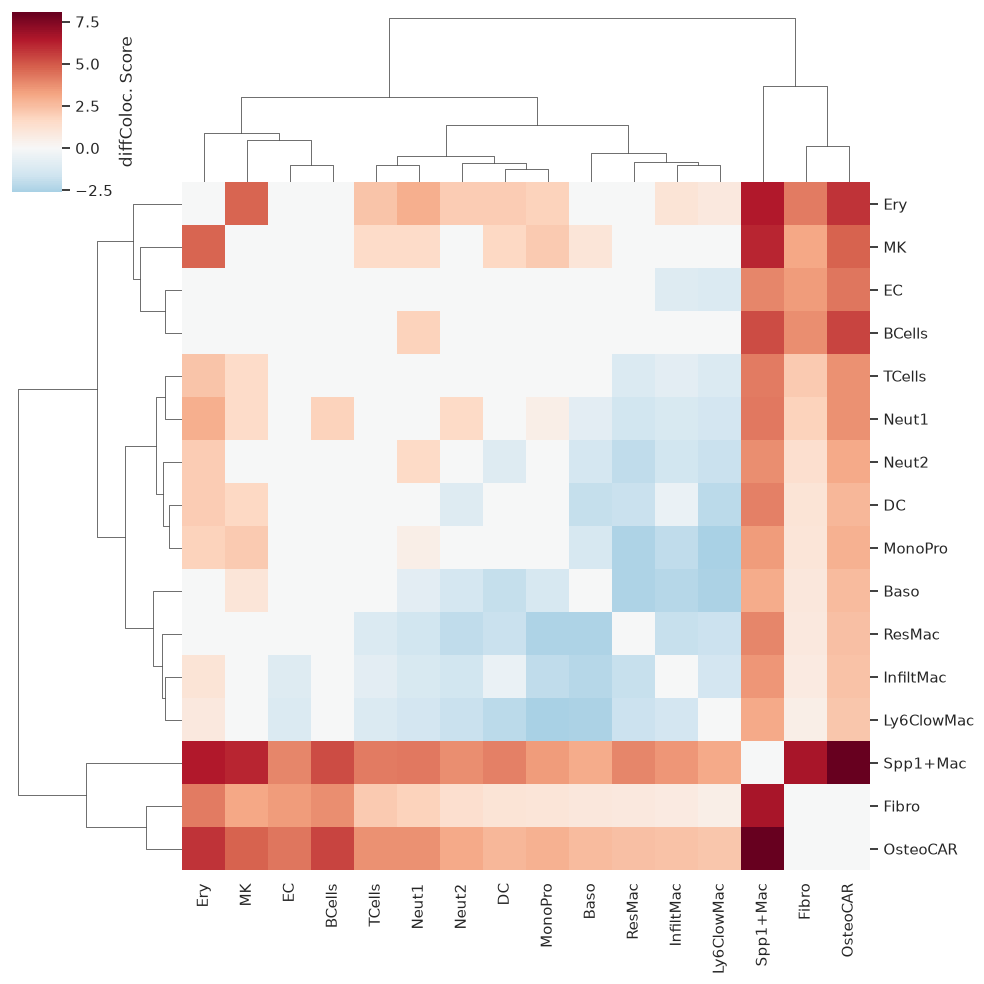

In [14]:
OvsE_TPO_HMdf, stats = nichesphere.coloc.OvsE_coloc_test_adjPval(
    observedColocProbs=colocPerSample.loc['TPO'],
    expectedColocProbs=scCTpairsProbs_TPO['count'],
    cell_types=CTprops.columns,
    testDistribution_df=bg_df,
    oneCTinteractions=oneCTints,
    p=0.1
)

sns.set(font_scale=1)
sns.clustermap(OvsE_TPO_HMdf, cmap='RdBu_r', center=0, method='ward', cbar_kws={'label': 'diffColoc. Score'})


`OvsE_coloc_test` also returns the underlying statistics:

In [15]:
stats.head()


,statistic,pvalue,adjusted_pvalue
DC-DC,0.000000,0.000,0.000000
DC-InfiltMac,-0.537164,0.000,0.000000
DC-Fibro,1.088154,0.000,0.000000
DC-MonoPro,0.000000,0.258,0.313024
DC-Neut2,-1.028178,0.002,0.003200


In [16]:
#stats.to_csv('../tutorial_results/diffcoloc_stats.csv')

## 4. Differential co-localization network

To build the differential co-localization network, we compute an adjacency matrix based on the Euclidean distances between the differential co-localization profiles of each cell type.

In [17]:
HMdist = pd.DataFrame(
    scipy.spatial.distance.squareform(scipy.spatial.distance.pdist(OvsE_TPO_HMdf)),
    columns=OvsE_TPO_HMdf.columns, index=OvsE_TPO_HMdf.index
)

HMsimm = 1 - HMdist / HMdist.max().max()
# Cell pairs with no significant differential co-localization get 0
HMsimm[OvsE_TPO_HMdf == 0] = 0


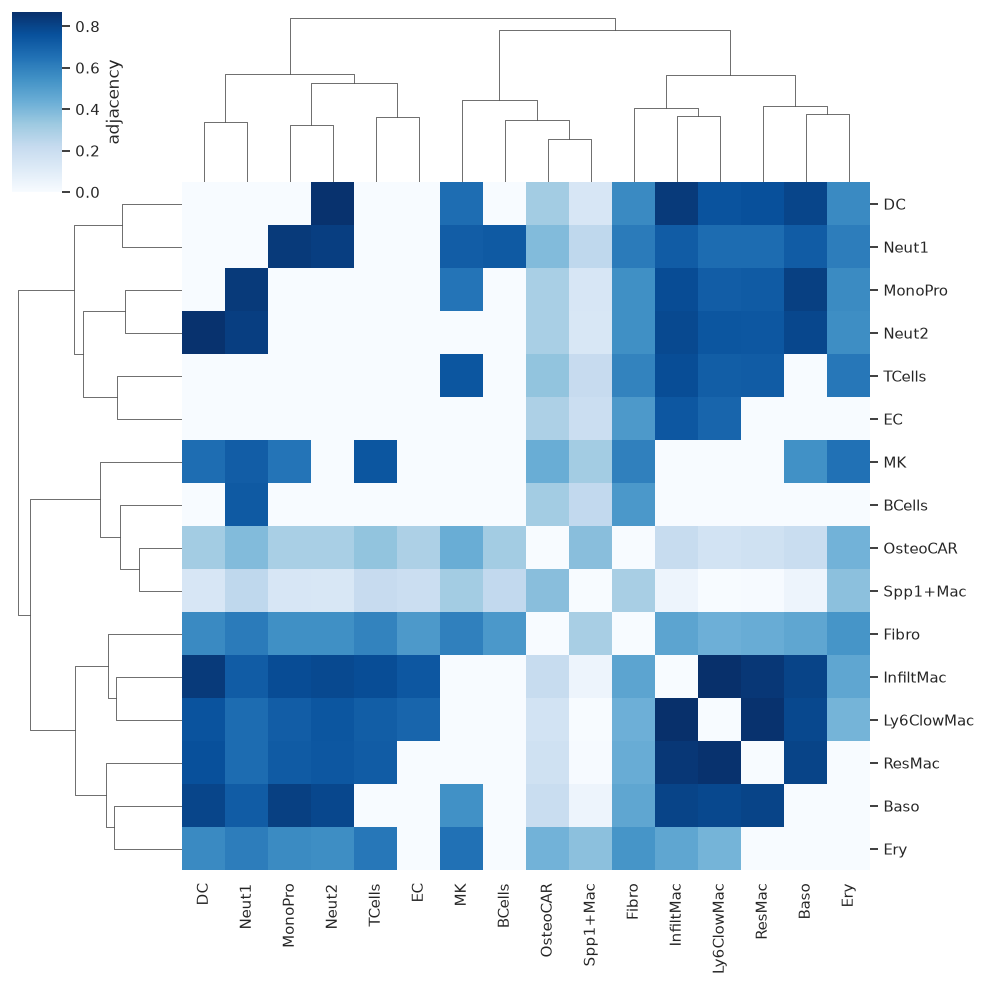

In [18]:
sns.set(font_scale=1)
sns.clustermap(HMsimm, cmap='Blues', method='ward', cbar_kws={'label': 'adjacency'})


### Niche detection

Before clustering the network into niches, we use a single placeholder group/color so that the initial network can be plotted with `coloc.colocNW`. The network is built from the differentially co-localized cell type pairs only.

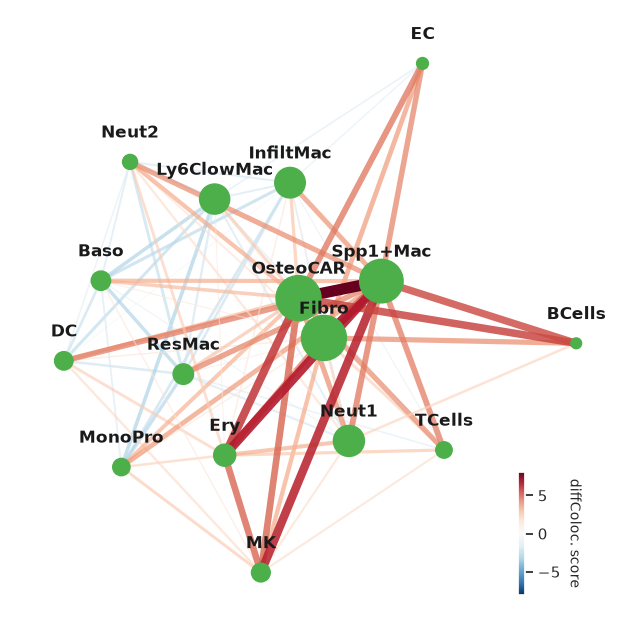

In [19]:
plt.rcParams['axes.facecolor'] = "None"

niches_dict = {'1_': list(OvsE_TPO_HMdf.index)}
clist = ['#4daf4a']

gCol = nichesphere.coloc.colocNW(x_diff=OvsE_TPO_HMdf, adj=HMsimm, cell_group=niches_dict,
                                  clist=clist, nodeSize='betweeness', layout='neato', thr=0)


We then detect communities (niches) in the unsigned network using Louvain clustering:

In [20]:
gCol2 = nx.from_pandas_adjacency(HMsimm, create_using=nx.Graph)

niches_raw = nx.algorithms.community.louvain_communities(gCol2, resolution=1.2, seed=1, weight='weight')
niches_dict = dict(enumerate([list(x) for x in niches_raw]))
niches_dict


{0: ['ResMac', 'DC', 'Baso', 'Neut2'],
 1: ['MK', 'Spp1+Mac', 'TCells', 'OsteoCAR', 'Ery'],
 2: ['Ly6ClowMac', 'InfiltMac', 'EC'],
 3: ['Fibro', 'Neut1', 'MonoPro', 'BCells']}

We can give the detected niches descriptive names and assign each a color for visualization:

In [21]:
#niche_names = ['1_Neut_ResMac_Baso_DC', '2_FibCore', '3_Macs_EC', '4_BCells_Fibro']
niche_names=['1_Resident_myeloid_niche', '2_FibCore', '3_Macrophage_vascular_niche', '4_Fibro_myeloid_niche']
niches_dict = dict(zip(niche_names, list(niches_dict.values())))

clist = ['#FF8C00', '#32CD32', '#E64B35', '#FFD700']
niche_cols = pd.Series(clist, index=list(niches_dict.keys()))
niches_df = nichesphere.tl.cells_niche_colors(CTs=CTprops.columns, niche_colors=niche_cols, niche_dict=niches_dict)


### Network layout

We use the `community-layout` package's `CommunityLayout` to lay out the network so that niches (communities) are visually grouped together. `CommunityLayout` is compatible with NetworkX (Hagberg et al., 2008) community detection functions, used internally via the `community_algorithm` and `community_kwargs` parameters.

In [22]:
from community_layout.layout_class import CommunityLayout

cl = CommunityLayout(
    gCol2,
    community_compression=0.4,
    layout_algorithm=nx.spring_layout,
    layout_kwargs={"k": 75, "iterations": 1000},
    community_algorithm=nx.algorithms.community.louvain_communities,
    community_kwargs={"resolution": 1.2, 'seed': 1, 'weight': 'weight'}
)

pos = cl.full_positions


COMMUNITY LAYOUT: Datashader not found, edge bundling not available
Building meta-graph
Metagraph is a Graph with 4 nodes and 6 edges


100%|██████████| 4/4 [00:00<00:00, 391.78it/s]


We can now plot the differential co-localization network with niches highlighted by color, using the community-aware layout:

In [23]:
# Load node positions
pos = np.load('../../data/BM_PICseq/diffColocNW_node_pos.npy',allow_pickle='TRUE').item()


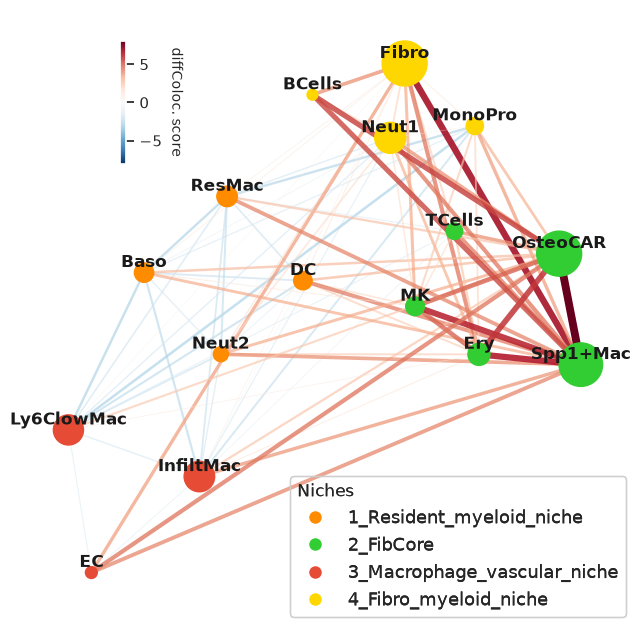

In [24]:
gCol = nichesphere.coloc.colocNW(
    x_diff=OvsE_TPO_HMdf,
    adj=HMsimm,
    cell_group=niches_dict,
    clist=clist,
    nodeSize='betweeness',
    layout=None,  # set to None when providing node positions
    lab_spacing=0.05,
    thr=0,
    pos=pos,
    edge_scale=0.7,
    legend_ax=[0.05, 0.75, 0.15, 0.2]
)

legend_elements = [
    plt.Line2D([0], [0], marker="o", color='w', markerfacecolor=clist[i], lw=4,
               label=list(niches_dict.keys())[i], ms=10)
    for i in range(len(niches_dict))
]
plt.gca().add_artist(plt.legend(handles=legend_elements, loc='lower right', fontsize=13,
                                 title='Niches', alignment='left'))

#plt.savefig('../figures/diffColocNW.pdf')


In [25]:
## Save node positions
#np.save('../tutorial_data/diffColocNW_node_positions.npy', pos) 


Finally, we assign niche/community information and node positions to the network object, so they can be reused for subsequent network visualizations:

In [26]:
nichesphere.tl.assign_properties(
    gCol,
    communities=cl.communities(),
    colors=clist,
    pos=pos,
    simmilarity_weights=True,
    node_coord_sf=100,
    g_unsigned=gCol2
)


### Interactive network

The `gravis` library enables an interactive D3-based network visualization where node sizes, edge widths, and label sizes can be adjusted in the browser. One can also move the nodes around to avoid overlaps.

> **Note:** gravis may require downgrading setuptools: `pip install --force-reinstall -U "setuptools<82.0.0"`


In [27]:
import gravis as gv
gv.d3(gCol, edge_size_data_source='weight_abs', zoom_factor=0.35, layout_algorithm_active=False)


### Network statistics

We can compute and visualize standard network statistics (betweenness centrality, PageRank, and degree centrality split by positive/negative edges). These are based on the implementations from [NetworkX](https://networkx.org/en/):

In [28]:
nw_stats = nichesphere.tl.compute_network_stats(gCol)
nw_stats.head()

,betweenness,pagerank,degree_positive,degree_negative
DC,22.697681,-1.020317,0.333333,0.333333
InfiltMac,-6.489179,-2.196781,0.266667,0.600000
Fibro,30.776810,2.731931,0.933333,0.000000
MonoPro,22.697681,-1.134020,0.400000,0.266667
Neut2,22.697681,-1.056960,0.333333,0.333333


In [29]:
#nw_stats.to_csv('../tutorial_results/diffColocNW_stats.csv')


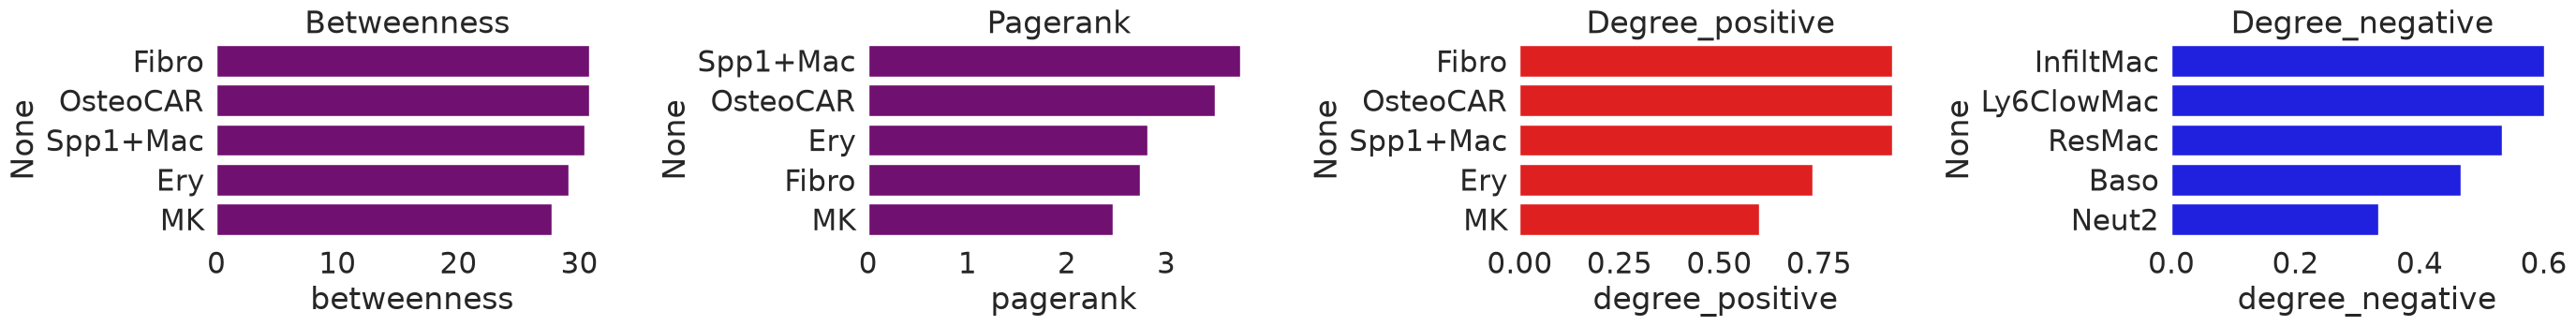

In [30]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = "None"
fig = nichesphere.tl.plot_top_stats(nw_stats, top_n=5)
#plt.savefig('../figures/diffColocNW_stats_top5.pdf')

### Niche cohesion: internal vs external edge weights

To assess how cohesive each detected niche is, we compare the distribution of co-localization scores for edges connecting cell types *within* the same niche (internal) against edges connecting cell types *across* niches (external). A niche with predominantly positive internal edges and weaker or negative external edges is more tightly co-localized internally than expected by chance.

We first build a partition map from the Louvain community detection result, then use `nichesphere.niche` to visualise and test the distributions.

In [31]:
# Map each cell type node to its named niche
d = nx.algorithms.community.louvain_communities(gCol2, resolution=1.2, seed=1, weight='weight')
vc_map = {node: i for i, members in enumerate(d) for node in members}

community_names = dict(enumerate(niche_names))  # reuse the niche_names list defined above
vc_map_named = {node: community_names[comm_id] for node, comm_id in vc_map.items()}

<Axes: title={'center': 'Internal vs external edge weight distributions by niche'}, xlabel='niche', ylabel='edge weight'>

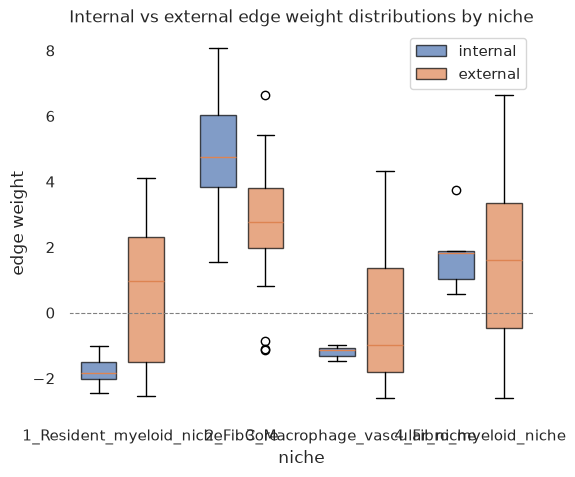

In [32]:
sns.set(font_scale=1)
plt.rcParams['axes.facecolor'] = "None"
nichesphere.niche_stats.plot_internal_external_boxplots(gCol, vc_map_named)
#plt.savefig('../figures/diffColocNW_int_ext_boxplots.pdf', bbox_inches='tight')

We can also obtain a flat summary table of edge counts and total weights per niche:

In [33]:
nichesphere.niche_stats.community_edge_stats_df(gCol, vc_map_named)

,internal_pos_count,internal_pos_weight,internal_neg_count,internal_neg_weight,external_pos_count,external_pos_weight,external_neg_count,external_neg_weight
community,,,,,,,,
1_Resident_myeloid_niche,0,0.000000,6,10.646399,17,38.125336,13,21.593805
2_FibCore,10,47.617059,0,0.000000,33,100.060348,3,3.114141
3_Macrophage_vascular_niche,0,0.000000,3,3.609690,10,23.011103,14,23.687616
4_Fibro_myeloid_niche,5,9.061479,0,0.000000,22,60.038467,8,13.486342


Finally, we test whether the internal and external edge weight distributions differ significantly for each niche using a Wilcoxon rank-sum test with FDR correction:

In [34]:
signed        = nichesphere.niche_stats.community_signed_weight_distributions(gCol, vc_map_named)
communities   = sorted(signed.keys())
internal_data = [signed[c]['internal'] for c in communities]
external_data = [signed[c]['external'] for c in communities]

nichesphere.niche_stats.pairwise_ranksums_int_ext(
    internal_data, external_data, communities, MTcorrection='fdr_bh'
)

,niche,statistic,p_value,p_value_corrected
0,1_Resident_myeloid_niche,-2.334620,0.019563,0.039127
1,2_FibCore,2.743012,0.006088,0.024351
2,3_Macrophage_vascular_niche,-0.308607,0.757621,0.850436
3,4_Fibro_myeloid_niche,0.188562,0.850436,0.850436


## 5. Process-based localized differential communication

One of Nichesphere's key features is process-based localized differential communication testing: looking at how ligand-receptor (LR) interactions belonging to specific biological processes change between niches across conditions.

To do this, we first need per-condition LR communication scores. We compute these by running [LIANA](https://github.com/saezlab/liana-py) and [pyCrossTalkeR](https://github.com/CostaLab/pyCrossTalkeR) on the raw singlets data.

### Preparing raw singlets data

The deconvolution/annotation steps above used processed data. For LR analysis we use the corresponding raw count matrix and store it in a new anndata object with the metadata to avoid changes in the already processed data:

In [35]:
import anndata as ad

adata_singlets_raw = ad.AnnData(
    X=adata_singlets.layers['counts'],
    obs=adata_singlets.obs,
    var=adata_singlets.var
)
adata_singlets_raw.raw = adata_singlets_raw

### Running LIANA and pyCrossTalkeR

For each condition, we compute LR interaction scores with LIANA's CellPhoneDB method, then convert the results into pyCrossTalkeR format and run the differential analysis between conditions:

In [36]:
import os
from pycrosstalker import tools as cttl
import liana as li

#adata_singlets_raw.raw = adata_singlets_raw

adata_singlets_raw.uns['liana'] = {}
for stage in set(adata_singlets_raw.obs['stage']):
    lr = li.method.cellphonedb(
        adata_singlets_raw[adata_singlets_raw.obs['stage'] == stage],
        groupby='annotation',
        expr_prop=0.1,
        verbose=True,
        resource_name='mouseconsensus',
        inplace=False
    )
    adata_singlets_raw.uns['liana'][stage] = lr

adata_singlets_raw = cttl.utils.from_liana(adata_singlets_raw)
adata_singlets_raw.uns['pycrosstalker']['details'] = {'filename': 'PICseq'}

output = './results/output_ctkr/PICseq/'
os.makedirs(output, exist_ok=True)
adata_singlets_raw = cttl.analise_LR(adata_singlets_raw, out_path=output, comparison=[('TPO', 'EV')])


Using resource `mouseconsensus`.
Using `.raw`!
Converting to sparse csr matrix!
1129 features of mat are empty, they will be removed.
Converting `annotation` to categorical!
0.30 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 12373 samples and 1070 features


100%|██████████| 1000/1000 [00:48<00:00, 20.51it/s]
Using resource `mouseconsensus`.
Using `.raw`!
Converting to sparse csr matrix!
1104 features of mat are empty, they will be removed.
Converting `annotation` to categorical!
0.28 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 14673 samples and 1084 features


100%|██████████| 1000/1000 [00:45<00:00, 22.15it/s]


Create a Differential Table
Calculating CCI Ranking
Calculating GCI Ranking


... storing 'annotation' as categorical


Network Analysis Done
Generating h5ad file with Analysed Results


### Mapping cell type pairs to niche pairs

Next we assign each cell type pair to its corresponding niche pair, so that communication scores can later be aggregated and compared at the niche level:

In [37]:
oneCTints = pd.Series(oneCTints)
pairCatDFdir = nichesphere.tl.get_pairCatDFdir(niches_df)
pairCatDFdir.head()


,cell_pairs,niche_pairs
0,DC->DC,1_Resident_myeloid_niche->1_Resident_myeloid_n...
1,DC->InfiltMac,1_Resident_myeloid_niche->3_Macrophage_vascula...
2,DC->Fibro,1_Resident_myeloid_niche->4_Fibro_myeloid_niche
3,DC->MonoPro,1_Resident_myeloid_niche->4_Fibro_myeloid_niche
4,DC->Neut2,1_Resident_myeloid_niche->1_Resident_myeloid_n...


### Filtering by co-localization

We restrict communication testing to cell type pairs with significant differential co-localization scores. Pairs with `filter==1` will be tested downstream:

In [38]:
colocFilt = nichesphere.tl.getColocFilter(pairCatDF=pairCatDFdir, adj=HMsimm,
                                           oneCTints=oneCTints.str.replace('-', '->'))
#colocFilt.to_csv('../tutorial_results/colocFilt.csv')
colocFilt.head()


,filter
cell_pairs,
DC->DC,1.0
DC->InfiltMac,1.0
DC->Fibro,1.0
DC->MonoPro,0.0
DC->Neut2,1.0


### CrossTalkeR communication tables

We retrieve the per-condition LR communication tables produced by pyCrossTalkeR. These contain a `cellpair` column (cell types involved, separated by `@`), an `allpair` column (cell types, ligand, and receptor), and columns for the ligand (`gene_A`), receptor (`gene_B`), and communication score (`MeanLR`). Column names can be customized in NicheSphere functions if your data differs.

CrossTalkeR tables also annotate genes as ligand (`|L`), receptor (`|R`), or transcription factor (`|TF`); we remove these suffixes as they can conflict with downstream code.

In [39]:
crossTalker_ctrlComm = adata_singlets_raw.uns['pycrosstalker']['path']['EV']
crossTalker_tpoComm = adata_singlets_raw.uns['pycrosstalker']['path']['TPO']

crossTalker_ctrlComm = nichesphere.tl.processCTKRoutput(crossTalker_ctrlComm)
crossTalker_tpoComm = nichesphere.tl.processCTKRoutput(crossTalker_tpoComm)


### Ligand-process database

To test differential communication per biological process, we load a database linking ligands to the processes they are involved in (compiled from several published ligand-receptor databases):

In [40]:
import nichesphere.database as db


In [41]:
# Load database
allDBs = db.load_DB()


In [42]:
allDBs['Ligand'] = allDBs['Ligand'].str.lower()
allDBs.head()


,Ligand,category,db,PMID
2,col1a1,Collagens,matrisome,36399478
3,col1a2,Collagens,matrisome,36399478
4,col1a1,Collagens,matrisome,36399478
5,col6a3,Collagens,matrisome,36399478
6,col1a2,Collagens,matrisome,36399478


In [43]:
allDBs_sub = allDBs[~allDBs.category.isin(['apoptosis', 'phagocytosis'])]
allDBs_sub = allDBs_sub.drop_duplicates()


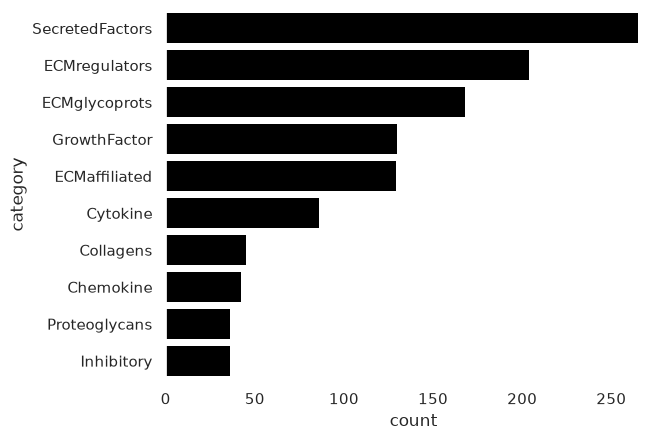

In [44]:
sns.set_context(rc={'patch.linewidth': 0.0})
sns.barplot(x=allDBs_sub.category.value_counts(), y=allDBs_sub.category.value_counts().index,
            data=pd.DataFrame(allDBs_sub.category.value_counts()), color='black')
sns.despine()


## 6. Differential communication testing

We now split communication scores by process, to determine which cell type pairs (and niche pairs) are communicating through which processes, in each condition. Interactions present in only one condition are assigned a score of 0 in the other, so conditions can be compared directly.

In [45]:
EV_scores = nichesphere.comm.lr_ctPairScores_perCat_dir(
    ccommTable=crossTalker_ctrlComm, db=allDBs_sub, dbCatCol='category', dbMatchCol='Ligand',
    ccommMatchCol='gene_A', ccommLRscoresCol='MeanLR',
    oneCTinteractions=oneCTints.str.replace('-', '@'), condition='EV', pairCatDF=pairCatDFdir
)

TPO_scores = nichesphere.comm.lr_ctPairScores_perCat_dir(
    ccommTable=crossTalker_tpoComm, db=allDBs_sub, dbCatCol='category', dbMatchCol='Ligand',
    ccommMatchCol='gene_A', ccommLRscoresCol='MeanLR',
    oneCTinteractions=oneCTints.str.replace('-', '@'), condition='TPO', pairCatDF=pairCatDFdir
)

EV_scores, TPO_scores = nichesphere.comm.equalizeScoresTables(
    ctrlTbl=EV_scores, expTbl=TPO_scores, ctrlCondition='EV', expCondition='TPO'
)


We then keep only the cell type pairs that passed the co-localization filter computed earlier:

In [46]:
sig_pairs = colocFilt.index[colocFilt['filter'] == 1]
EV_scores = EV_scores[[i in sig_pairs for i in EV_scores.cell_pairs]]
TPO_scores = TPO_scores[[i in sig_pairs for i in TPO_scores.cell_pairs]]

TPO_scores.LRcat.value_counts()


LRcat
SecretedFactors    1999
ECMregulators      1453
ECMglycoprots      1366
GrowthFactor       1190
Cytokine            918
Collagens           679
ECMaffiliated       620
Proteoglycans       275
Chemokine           265
Inhibitory          151
Name: count, dtype: int64

### Differential communication per niche pair

`comm.diffCcommStats` tests for differential communication between groups of interactions across processes. Setting `cellCatCol='niche_pairs'` aggregates results at the niche-pair level:

In [47]:
diffComm_niches = nichesphere.comm.diffCcommStats(
    c1CTpairScores_byCat=TPO_scores, c2CTpairScores_byCat=EV_scores, cellCatCol='niche_pairs'
)


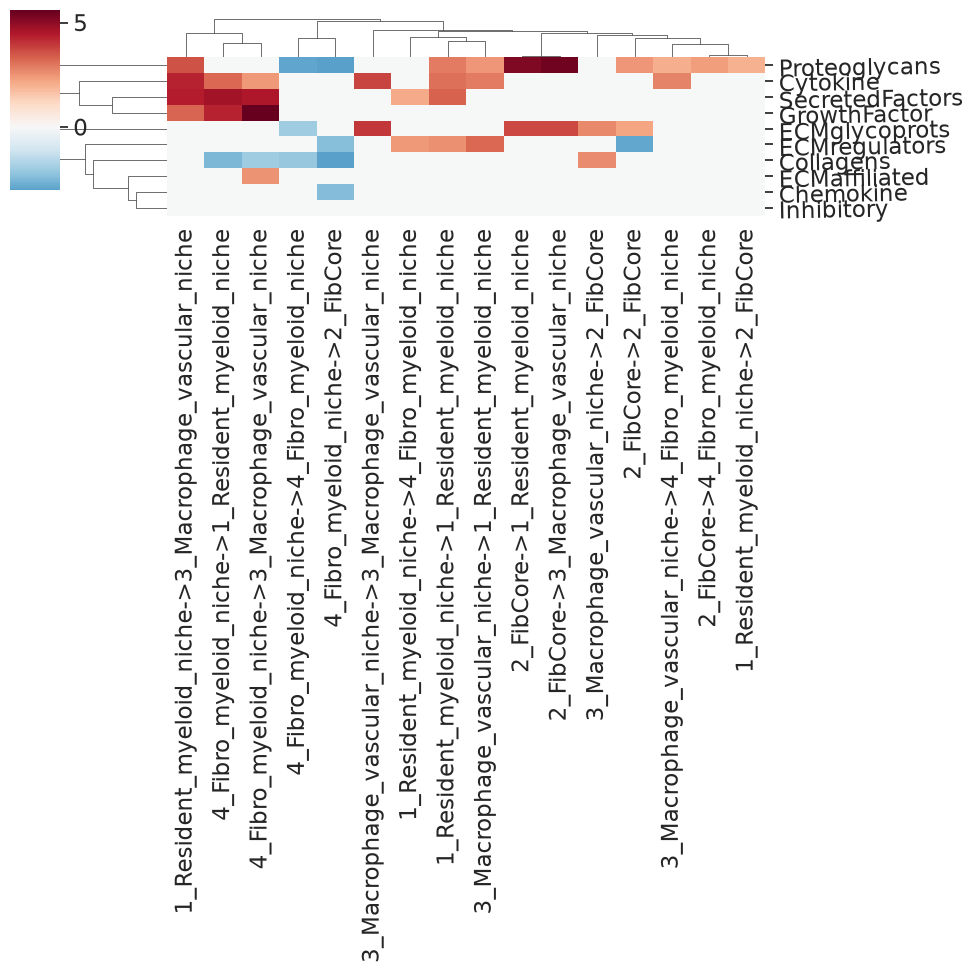

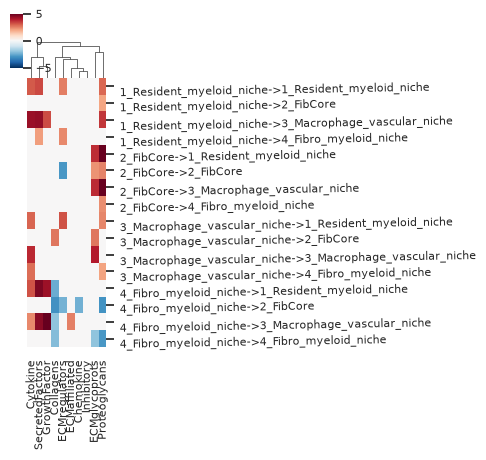

In [48]:
hm_df, _ = nichesphere.comm.plotDiffCcommStatsHM(diffCommTable=diffComm_niches, min_pval=0.05)
hm_df = hm_df.T[hm_df.sum() != 0].T

cm = sns.clustermap(hm_df.T.sort_index(), cmap='RdBu_r', center=0, method='complete',
                     row_cluster=False, vmin=-5, vmax=5)
plt.setp(cm.ax_heatmap.yaxis.get_majorticklabels(), rotation=1, fontsize=8)
plt.setp(cm.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)

# Tidy up the figure layout
hm = cm.ax_heatmap.get_position()
cm.ax_heatmap.set_position([hm.x0, hm.y0, hm.width * 0.5, hm.height * 0.45])
col = cm.ax_col_dendrogram.get_position()
cm.ax_col_dendrogram.set_position([col.x0, col.y0 * 0.6, col.width * 0.5, col.height * 0.25])
row = cm.ax_row_dendrogram.get_position()
cm.ax_row_dendrogram.set_position([row.x0 * 3.5, row.y0, row.width * 0.2, row.height * 0.45])
x0, y0, w, h = cm.cbar_pos
cm.ax_cbar.set_position([x0 * 2.5, y0 * 0.63, w * 0.25, h * 0.3])
cm.tick_params(labelsize=8)

#plt.savefig('../figures/diffComm_byNichePair_byProcess.pdf')
plt.show()


### Differential communication per cell type pair

To build process-specific differential communication networks, we repeat the test with `cellCatCol='cell_pairs'`, giving differential communication scores per cell type pair (rather than per niche pair):

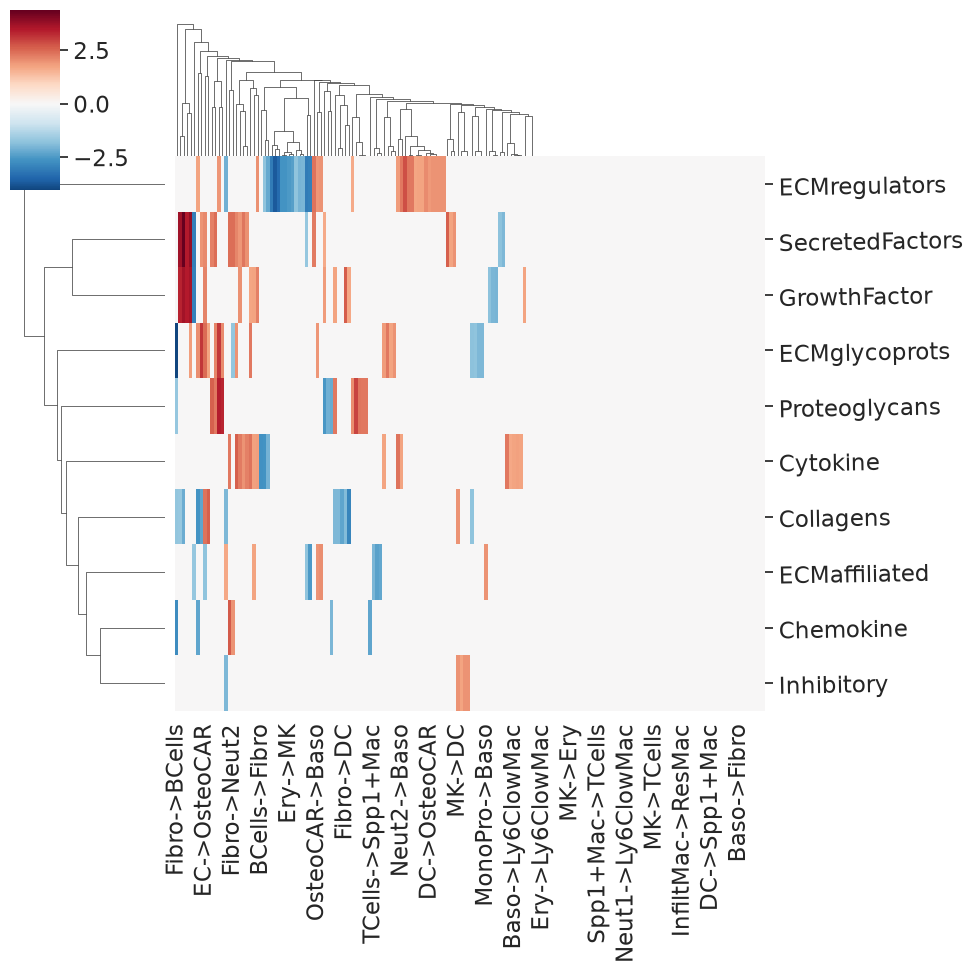

In [49]:
diffComm_ctpairs = nichesphere.comm.diffCcommStats(
    c1CTpairScores_byCat=TPO_scores, c2CTpairScores_byCat=EV_scores, cellCatCol='cell_pairs'
)

x_EVtpo_dir, _ = nichesphere.comm.plotDiffCcommStatsHM(diffCommTable=diffComm_ctpairs, min_pval=0.1)


## 7. Localized differential communication networks

We can now overlay process-specific differential communication scores onto the co-localization network: for each process category, edges represent differential communication between niches/cell types, computed with `comm.getDiffComm` and visualized with `comm.catNW`.

### Single-process network: example

To produce a polished figure for a single process (e.g. `ECMglycoprots`), we plot the network using the saved community-aware layout (`pos`):

In [50]:
plt.rcParams['axes.facecolor'] = "None"

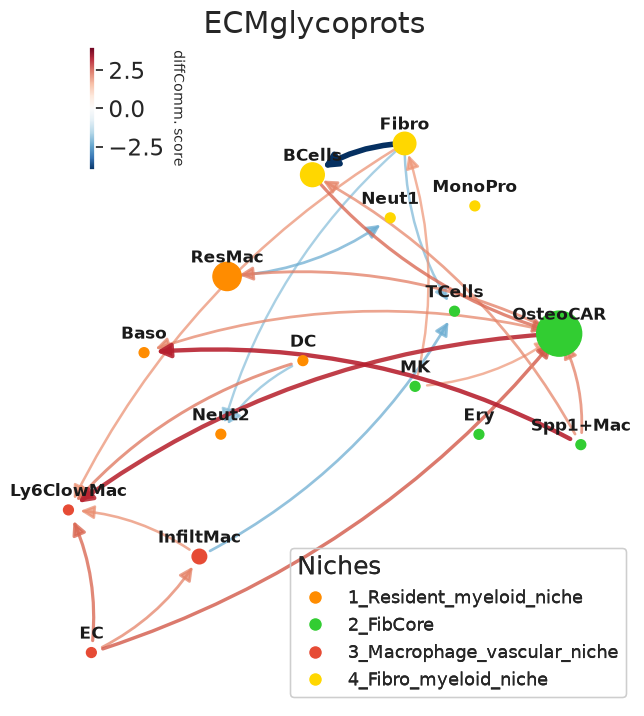

In [51]:
cat = 'ECMglycoprots'
x_chem = nichesphere.comm.getDiffComm(diffCommTbl=x_EVtpo_dir, pairCatDF=pairCatDFdir, ncells=16, cat=cat)

G = nichesphere.comm.catNW(x_chem=x_chem, colocNW=gCol, cell_group=niches_dict, group_cmap='tab20',
                            ncols=20, plot_title=cat, clist=clist, nodeSize='betweeness',
                            legend_ax=[0.0, 0.87, 0.15, 0.2], pos=pos, thr=0, layout=None, lab_spacing=0.05)

legend_elements = [
    plt.Line2D([0], [0], marker="o", color='w', markerfacecolor=clist[i], lw=4,
               label=list(niches_dict.keys())[i], ms=10)
    for i in range(len(niches_dict))
]
plt.gca().add_artist(plt.legend(handles=legend_elements, loc='lower right', fontsize=13,
                                 title='Niches', alignment='left'))
#plt.savefig(f'../figures/commNW_{cat}.pdf')


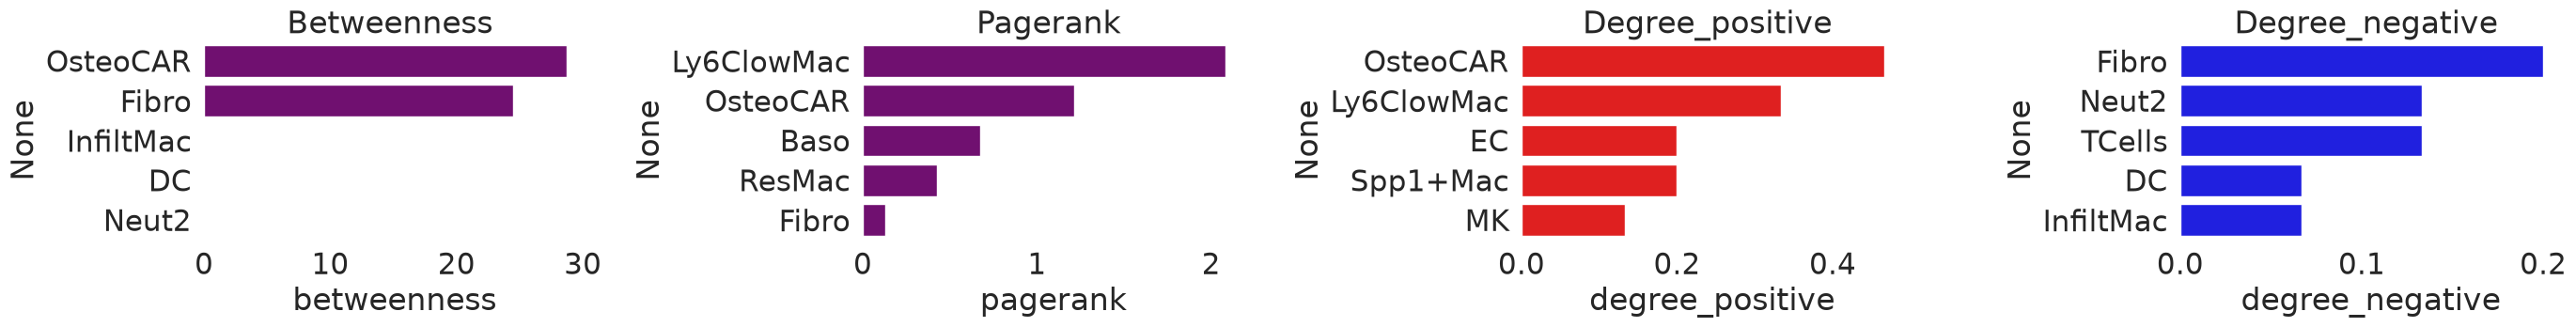

In [52]:
nw_stats_cat = nichesphere.tl.compute_network_stats(G)

sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = "None"
fig = nichesphere.tl.plot_top_stats(nw_stats_cat, top_n=5)
#plt.savefig(f'../figures/commNW_{cat}_stats_top5.pdf', bbox_inches='tight')


## 8. Visualizing ligand-receptor interactions with Sankey diagrams

Finally, we can visualize selected ligand-receptor relationships as Sankey diagrams using pyCrossTalkeR's results and NicheSphere's **sankey_plot** module, for cell type pairs/processes of interest.

We start from the differential communication table (`TPO_x_EV`), restricted to the co-localization-filtered cell type pairs:


**Example 1:** Spp1 signaling from Spp1+ macrophages:

Plotting 25 distinct fluid flow paths.


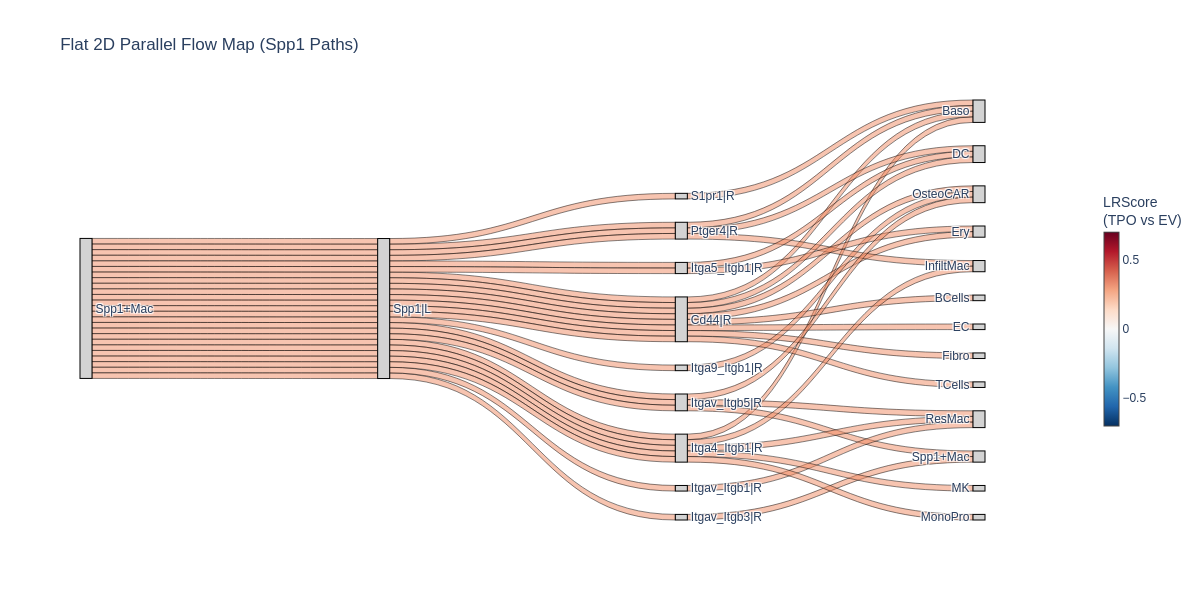

In [53]:
fig2=nichesphere.sankey_plot.plot_custom_sankey(
    adata=adata_singlets_raw,
    table_key='TPO_x_EV',
    filter_df=colocFilt,
    source_cell='Spp1+Mac',
    ligand_gene='Spp1',
    threshold=25,
    title="Flat 2D Parallel Flow Map (Spp1 Paths)",
    #save_path="spp1Macs_spp1_sankey.pdf"
)
fig2.show()

**Example 2:** ECM glycoprotein signaling within the fibrotic core niche:

Plotting 25 distinct fluid flow paths.


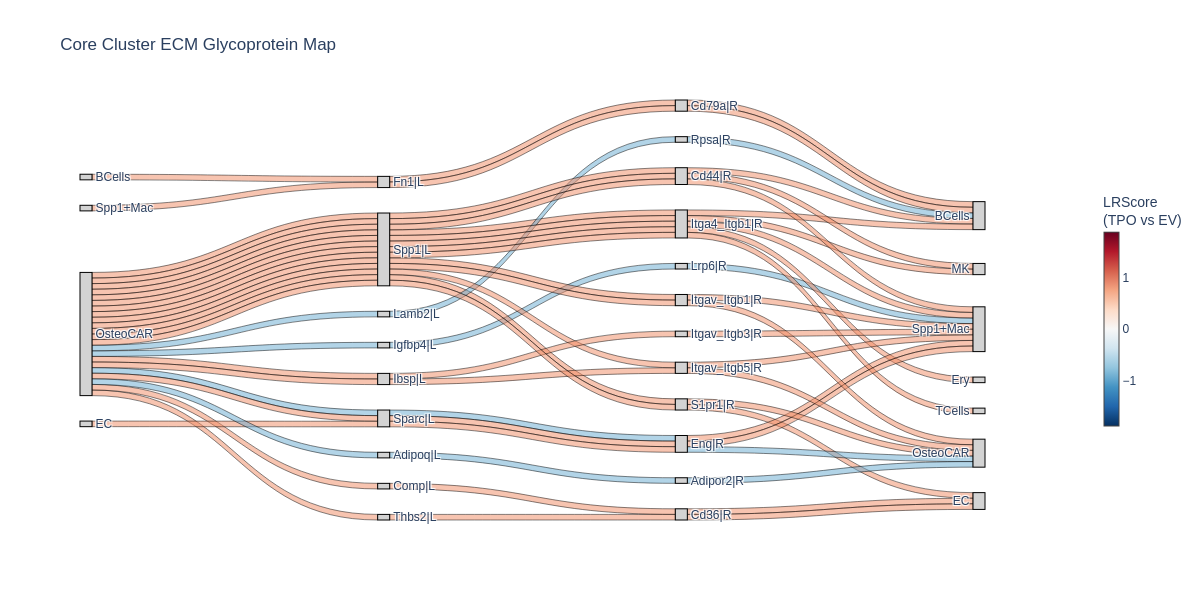

In [54]:
# Setup variables
ECM_GPs = list(allDBs_sub.Ligand[allDBs_sub.category == 'ECMglycoprots'])
fibCore = ['Spp1+Mac', 'BCells', 'MK', 'TCells', 'EC', 'OsteoCAR', 'Ery']

# Generate chart inline and save vector out
fig = nichesphere.sankey_plot.plot_custom_sankey(
    adata=adata_singlets_raw,
    table_key='TPO_x_EV',
    filter_df=colocFilt,
    source_cell=fibCore,
    target_cell=fibCore,
    ligand_list=ECM_GPs,
    threshold=25,
    title="Core Cluster ECM Glycoprotein Map",
    #save_path="fibCore_ECMglycoprots_sankey.pdf" # <-- Bypasses Python bugs and downloads vector directly via browser!
)
fig.show()

---

This concludes the tutorial. We have shown how to:

- Compute cell type pair co-localization probabilities from spatial/PIC-seq deconvolution data
- Test differential co-localization against a background distribution and build a differential co-localization network
- Detect niches (communities) within this network
- Compute process-based differential cell-cell communication from CrossTalkeR/LIANA output
- Combine co-localization and communication into localized differential communication networks
- Visualize specific ligand-receptor relationships with Sankey diagrams

For more details on individual functions, see the [NicheSphere documentation](https://github.com/CostaLab/Nichesphere).